In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.style.use('ggplot')
import seaborn as sns

# import plotly.express as px
# import plotly.graph_objects as go
# import plotly.figure_factory as ff
# from plotly.colors import n_colors
# from plotly.subplots import make_subplots

# from bokeh.plotting import figure
# from bokeh.io import output_notebook, show, output_file
# from bokeh.models import ColumnDataSource, HoverTool, Panel, Tabs

orange_black = ['#fdc029', '#df861d', '#FF6347', '#aa3d01', '#a30e15', '#800000', '#171820']
print('Done setup library!')


Done setup library!


In [2]:
df = pd.read_csv("../data/raw/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6378 non-null   int64 
 1   Attendance                  6378 non-null   int64 
 2   Parental_Involvement        6378 non-null   object
 3   Access_to_Resources         6378 non-null   object
 4   Extracurricular_Activities  6378 non-null   object
 5   Sleep_Hours                 6378 non-null   int64 
 6   Previous_Scores             6378 non-null   int64 
 7   Motivation_Level            6378 non-null   object
 8   Internet_Access             6378 non-null   object
 9   Tutoring_Sessions           6378 non-null   int64 
 10  Family_Income               6378 non-null   object
 11  Teacher_Quality             6378 non-null   object
 12  School_Type                 6378 non-null   object
 13  Peer_Influence              6378 non-null   object
 1

In [8]:
# rename columns
df.columns = [
    "hours_studied",
    "attendance",
    "parental_involvement",
    "resources",
    "extracurricular",
    "sleep_hours",
    "previous_scores",
    "motivation",
    "internet",
    "tutoring",
    "family_income",
    "teacher_quality",
    "school_type",
    "peer_influence",
    "physical_activity",
    "learning_disability",
    "parent_education",
    "distance",
    "gender",
    "exam_score"
]

# clean categories
for col in df.select_dtypes(include = ['object', 'string']).columns:
    df[col] = (
        df[col]
        .str.lower()
        .str.replace(" ", "_")
        .str.strip()
    )

# export final
# df.to_csv("../data/processed/clean_student_performance.csv", index=False)

print("DONE EXPORT")

DONE EXPORT


=== MỨC ĐỘ TƯƠNG QUAN VỚI ĐIỂM THI (EXAM SCORE) ===
                   exam_score
exam_score           1.000000
attendance           0.580259
hours_studied        0.445104
previous_scores      0.174283
tutoring             0.156829
physical_activity    0.025148
sleep_hours         -0.017171
--------------------------------------------------


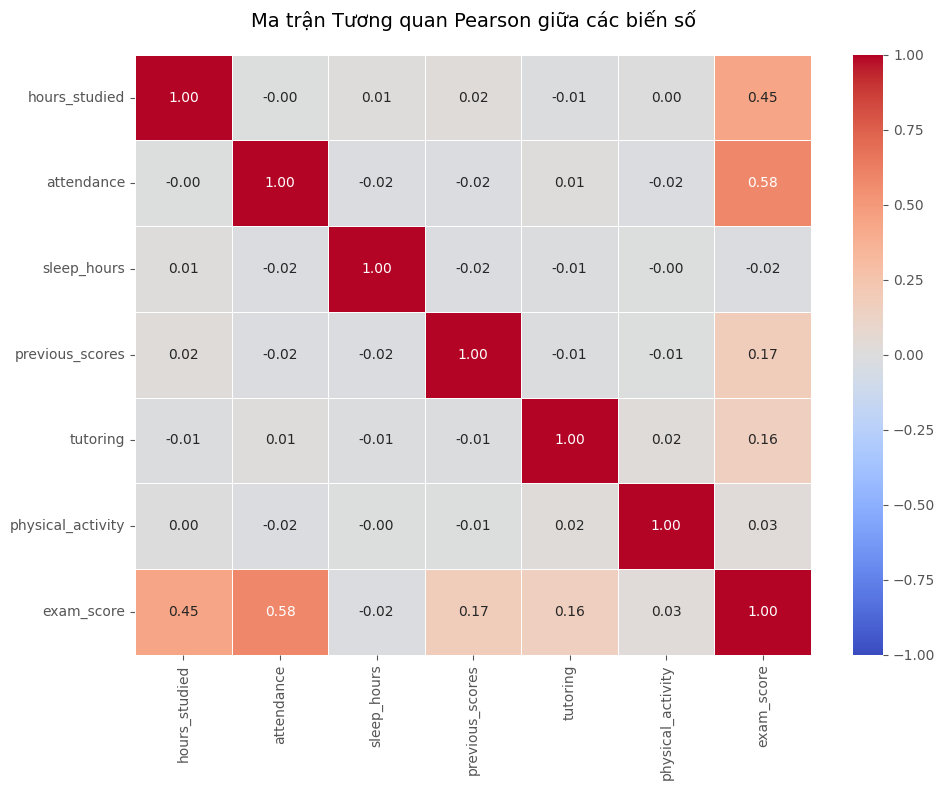

In [9]:
# Cell 1: Phân tích Tương quan Tuyến tính (Pearson Correlation)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tự động lọc các cột dạng số học (numeric)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Tính toán ma trận tương quan Pearson
corr_matrix = numeric_df.corr(method='pearson')

# 3. Lọc riêng tương quan của các biến đối với target 'exam_score'
target_corr = corr_matrix[['exam_score']].sort_values(by='exam_score', ascending=False)
print("=== MỨC ĐỘ TƯƠNG QUAN VỚI ĐIỂM THI (EXAM SCORE) ===")
print(target_corr)
print("-" * 50)

# 4. Trực quan hóa bằng Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Ma trận Tương quan Pearson giữa các biến số", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [10]:
# Cell 2: Kiểm định Hồi quy - Tác động của Attendance đến Exam Score
import statsmodels.api as sm

# Khai báo biến
X_att = df['attendance']
y = df['exam_score']

# Thêm hằng số (Intercept) để phương trình có dạng: y = ax + b
X_att_sm = sm.add_constant(X_att)

# Khớp mô hình hồi quy OLS
model_att = sm.OLS(y, X_att_sm).fit()

# Tính hệ số tương quan r
r_att = df['attendance'].corr(df['exam_score'])

print("=== BÁO CÁO HỒI QUY: ATTENDANCE VS EXAM SCORE ===")
print(f"- Hệ số tương quan (Pearson r): {r_att:.3f}")
print(f"- Hệ số xác định (R-squared): {model_att.rsquared:.3f} ({model_att.rsquared * 100:.1f}%)")
print(f"- Hệ số góc (Coefficient của Attendance): {model_att.params['attendance']:.4f}")
print(f"- P-value: {model_att.pvalues['attendance']:.5e}")
print("-" * 50)
print("=> INSIGHT: Mỗi 1% Attendance tăng thêm, điểm thi tăng trung bình {:.2f} điểm.".format(model_att.params['attendance']))
print(f"=> INSIGHT: Mức độ chuyên cần giải thích {model_att.rsquared * 100:.1f}% sự khác biệt về điểm số.")

=== BÁO CÁO HỒI QUY: ATTENDANCE VS EXAM SCORE ===
- Hệ số tương quan (Pearson r): 0.580
- Hệ số xác định (R-squared): 0.337 (33.7%)
- Hệ số góc (Coefficient của Attendance): 0.1966
- P-value: 0.00000e+00
--------------------------------------------------
=> INSIGHT: Mỗi 1% Attendance tăng thêm, điểm thi tăng trung bình 0.20 điểm.
=> INSIGHT: Mức độ chuyên cần giải thích 33.7% sự khác biệt về điểm số.


In [11]:
# Cell 3: Kiểm định Hồi quy - Tác động của Study Hours đến Exam Score
# Khai báo biến
X_study = df['hours_studied']

# Thêm hằng số (Intercept)
X_study_sm = sm.add_constant(X_study)

# Khớp mô hình
model_study = sm.OLS(y, X_study_sm).fit()

# Tính hệ số tương quan r
r_study = df['hours_studied'].corr(df['exam_score'])

print("=== BÁO CÁO HỒI QUY: STUDY HOURS VS EXAM SCORE ===")
print(f"- Hệ số tương quan (Pearson r): {r_study:.3f}")
print(f"- Hệ số xác định (R-squared): {model_study.rsquared:.3f} ({model_study.rsquared * 100:.1f}%)")
print(f"- Hệ số góc (Coefficient của Study Hours): {model_study.params['hours_studied']:.4f}")
print(f"- P-value: {model_study.pvalues['hours_studied']:.5e}")
print("-" * 50)
print("=> INSIGHT: Mỗi 1 giờ học tăng thêm, điểm thi tăng trung bình {:.2f} điểm.".format(model_study.params['hours_studied']))
print(f"=> GIẢI MÃ CALLOUT: Thời gian tự học giải thích chính xác {model_study.rsquared * 100:.1f}% sự khác biệt về điểm số của học sinh.")

=== BÁO CÁO HỒI QUY: STUDY HOURS VS EXAM SCORE ===
- Hệ số tương quan (Pearson r): 0.445
- Hệ số xác định (R-squared): 0.198 (19.8%)
- Hệ số góc (Coefficient của Study Hours): 0.2911
- P-value: 4.52480e-308
--------------------------------------------------
=> INSIGHT: Mỗi 1 giờ học tăng thêm, điểm thi tăng trung bình 0.29 điểm.
=> GIẢI MÃ CALLOUT: Thời gian tự học giải thích chính xác 19.8% sự khác biệt về điểm số của học sinh.


In [12]:
# Cell 4: Phân tích Quartile và Kiểm định T-Test (Top vs Bottom)
from scipy import stats

# 1. Xác định ngưỡng điểm cho Top 25% và Bottom 25%
q75 = df['exam_score'].quantile(0.75)
q25 = df['exam_score'].quantile(0.25)

# 2. Phân tách tập dữ liệu
top_students = df[df['exam_score'] >= q75]
bottom_students = df[df['exam_score'] <= q25]

# 3. Tính toán Average Exam Score cho 2 nhóm
avg_top = top_students['exam_score'].mean()
avg_bottom = bottom_students['exam_score'].mean()
score_gap = avg_top - avg_bottom

print("=== SO SÁNH NHÓM XUẤT SẮC (TOP 25%) VÀ NHÓM YẾU (BOTTOM 25%) ===")
print(f"- Ngưỡng điểm Top 25%: >= {q75}")
print(f"- Ngưỡng điểm Bottom 25%: <= {q25}")
print(f"- Điểm trung bình Top 25%: {avg_top:.1f}")
print(f"- Điểm trung bình Bottom 25%: {avg_bottom:.1f}")
print(f"=> CHÊNH LỆCH (GAP): +{score_gap:.1f} điểm")
print("-" * 50)

# 4. Kiểm định T-Test độc lập để xác nhận sự khác biệt là có ý nghĩa thống kê
t_stat, p_val = stats.ttest_ind(top_students['exam_score'], bottom_students['exam_score'])
print("Kiểm định T-Test:")
print(f"- T-statistic: {t_stat:.2f}")
print(f"- P-value: {p_val:.5e}")
if p_val < 0.05:
    print("=> KẾT LUẬN: Sự chênh lệch điểm số giữa 2 nhóm là hoàn toàn đáng tin cậy về mặt thống kê (không phải do ngẫu nhiên).")

=== SO SÁNH NHÓM XUẤT SẮC (TOP 25%) VÀ NHÓM YẾU (BOTTOM 25%) ===
- Ngưỡng điểm Top 25%: >= 69.0
- Ngưỡng điểm Bottom 25%: <= 65.0
- Điểm trung bình Top 25%: 71.2
- Điểm trung bình Bottom 25%: 63.3
=> CHÊNH LỆCH (GAP): +7.9 điểm
--------------------------------------------------
Kiểm định T-Test:
- T-statistic: 94.46
- P-value: 0.00000e+00
=> KẾT LUẬN: Sự chênh lệch điểm số giữa 2 nhóm là hoàn toàn đáng tin cậy về mặt thống kê (không phải do ngẫu nhiên).


=== TOP 10 YẾU TỐ ẢNH HƯỞNG NHẤT ĐẾN ĐIỂM SỐ (DỰA TRÊN MỨC ĐỘ GIẢM NHIỄU LOẠN) ===
Base_Feature
family_income           0.015274
peer_influence          0.016144
physical_activity       0.024878
sleep_hours             0.026624
resources               0.029368
parental_involvement    0.033041
tutoring                0.037361
previous                0.088817
hours                   0.245143
attendance              0.385146
Name: Importance, dtype: float64


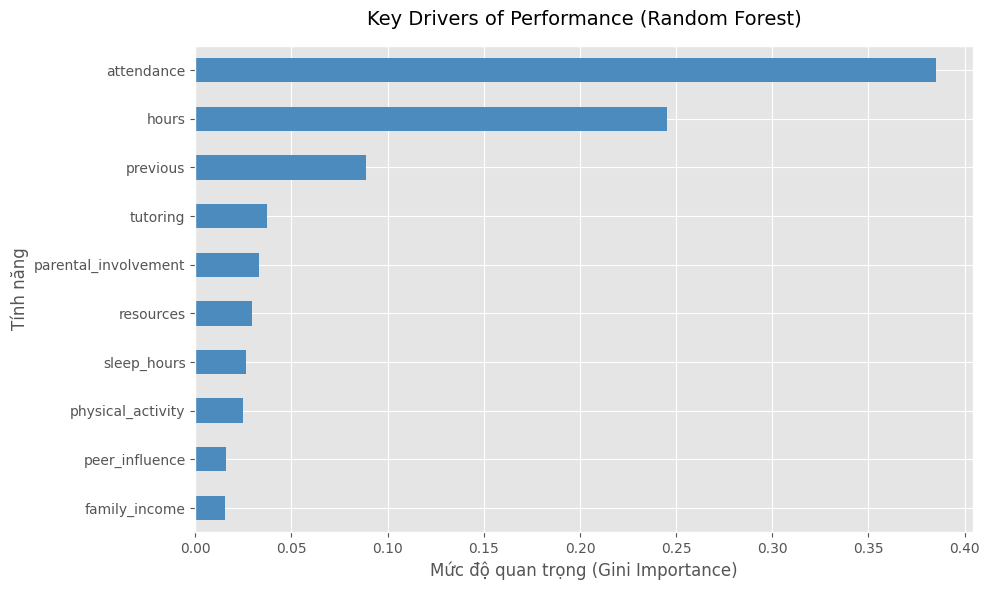

In [13]:
# Cell 5: Feature Importance bằng Random Forest (Bao gồm biến Categorical)
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Mã hóa One-Hot Encoding cho các biến phân loại
# drop_first=True để tránh bẫy đa cộng tuyến (dummy variable trap)
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Tách biến độc lập (X) và biến phụ thuộc (y)
X_rf = df_encoded.drop('exam_score', axis=1)
y_rf = df_encoded['exam_score']

# 3. Khởi tạo và huấn luyện mô hình Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_rf, y_rf)

# 4. Trích xuất mức độ quan trọng (Feature Importances)
importances = rf_model.feature_importances_
feature_names = X_rf.columns

# Đưa vào DataFrame và sắp xếp
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Gộp các dummy variables lại để dễ nhìn (Tùy chọn nâng cao)
# Ví dụ: gộp parental_involvement_medium và parental_involvement_high thành biến tổng
rf_importance_df['Base_Feature'] = rf_importance_df['Feature'].apply(lambda x: x.rsplit('_', 1)[0] if '_' in x and not x.endswith(('hours', 'score', 'activity')) else x)
agg_importance = rf_importance_df.groupby('Base_Feature')['Importance'].sum().sort_values(ascending=True)

print("=== TOP 10 YẾU TỐ ẢNH HƯỞNG NHẤT ĐẾN ĐIỂM SỐ (DỰA TRÊN MỨC ĐỘ GIẢM NHIỄU LOẠN) ===")
print(agg_importance.tail(10))

# 5. Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))
agg_importance.tail(10).plot(kind='barh', color='#4b8bbe')
plt.title("Key Drivers of Performance (Random Forest)", fontsize=14, pad=15)
plt.xlabel("Mức độ quan trọng (Gini Importance)")
plt.ylabel("Tính năng")
plt.tight_layout()
plt.show()

In [14]:
# Cell 6: Phân cụm Hành vi học tập (K-Means Clustering)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Chọn các biến hành vi để phân cụm
cluster_features = ['hours_studied', 'attendance', 'sleep_hours']
X_cluster = df[cluster_features]

# 2. Chuẩn hóa dữ liệu (Bắt buộc cho K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Chạy thuật toán K-Means (Giả sử chọn K=3 để tạo 3 chân dung học sinh)
# Bạn có thể dùng phương pháp Elbow (Elbow Method) để tìm K tối ưu nếu muốn đi sâu hơn
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['persona_cluster'] = kmeans.fit_predict(X_scaled)

# 4. Phân tích đặc điểm của từng Cụm (Cluster)
cluster_analysis = df.groupby('persona_cluster').agg({
    'hours_studied': 'mean',
    'attendance': 'mean',
    'sleep_hours': 'mean',
    'exam_score': ['mean', 'count']
}).round(1)

# Đổi tên cột cho dễ đọc
cluster_analysis.columns = ['Avg_Study_Hours', 'Avg_Attendance', 'Avg_Sleep_Hours', 'Avg_Exam_Score', 'Student_Count']
cluster_analysis = cluster_analysis.sort_values(by='Avg_Exam_Score', ascending=False)

print("=== CHÂN DUNG HỌC SINH TỪ THUẬT TOÁN K-MEANS ===")
print(cluster_analysis)

=== CHÂN DUNG HỌC SINH TỪ THUẬT TOÁN K-MEANS ===
                 Avg_Study_Hours  Avg_Attendance  Avg_Sleep_Hours  \
persona_cluster                                                     
2                           19.8            91.8              6.8   
1                           20.3            74.6              8.7   
0                           19.9            71.3              6.0   

                 Avg_Exam_Score  Student_Count  
persona_cluster                                 
2                          69.5           2423  
1                          66.3           1741  
0                          65.5           2214  


=== BÁO CÁO HIỆU SUẤT MÔ HÌNH DỰ BÁO RỦI RO ===
              precision    recall  f1-score   support

    Safe (0)       0.90      0.97      0.93       861
 At Risk (1)       0.92      0.79      0.85       415

    accuracy                           0.91      1276
   macro avg       0.91      0.88      0.89      1276
weighted avg       0.91      0.91      0.91      1276



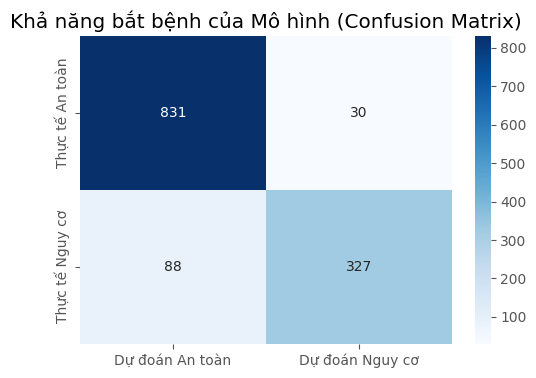


=> DEMO THỰC TẾ: Hệ thống cảnh báo học sinh này có 7.0% nguy cơ rơi vào nhóm Bottom 25%.


In [15]:
# Cell 7: Mô hình Dự báo Rủi ro (Random Forest Classifier)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Tạo biến mục tiêu: Ai có điểm <= ngưỡng Q25 (65.0) sẽ bị gán nhãn 1 (At Risk)
q25 = df['exam_score'].quantile(0.25)
df_encoded['is_at_risk'] = (df_encoded['exam_score'] <= q25).astype(int)

# 2. Chuẩn bị dữ liệu (Loại bỏ các cột điểm thi để tránh gian lận - Data Leakage)
X_class = df_encoded.drop(['exam_score', 'is_at_risk'], axis=1)
y_class = df_encoded['is_at_risk']

# 3. Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# 4. Huấn luyện mô hình Phân loại
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

# 5. Đánh giá mô hình trên tập Test
y_pred = rf_classifier.predict(X_test)

print("=== BÁO CÁO HIỆU SUẤT MÔ HÌNH DỰ BÁO RỦI RO ===")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'At Risk (1)']))

# 6. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dự đoán An toàn', 'Dự đoán Nguy cơ'], yticklabels=['Thực tế An toàn', 'Thực tế Nguy cơ'])
plt.title("Khả năng bắt bệnh của Mô hình (Confusion Matrix)")
plt.show()

# 7. Demo thực tế: Dự đoán cho 1 học sinh mới (Ví dụ lấy dòng đầu tiên trong tập Test)
sample_student = X_test.iloc[[0]]
risk_probability = rf_classifier.predict_proba(sample_student)[0][1] # Tỷ lệ rơi vào lớp 1 (At Risk)
print(f"\n=> DEMO THỰC TẾ: Hệ thống cảnh báo học sinh này có {risk_probability * 100:.1f}% nguy cơ rơi vào nhóm Bottom 25%.")